# Packaged vs Traditional Indian Foods — Combined Nutrition Analysis

This notebook combines two datasets and compares them on a common nutritional footing:

| Dataset | Rows | What it is |
|---|---|---|
| `packaged_foods_india.csv` | 852 | Branded packaged products (biscuits, chocolates, snacks, juices, instant foods…) with label nutrition, ingredients and price |
| `Indian_Food_Nutrition_Processed.csv` | 1,014 | Home-cooked / traditional Indian dishes (curries, dals, sweets, snacks, drinks…) with nutrient composition |

**Approach**

1. Load and profile both datasets
2. Clean the packaged data (text-typed numbers, `<x` values, typos, per-serving → per-100 g, kJ/kcal mix-ups)
3. Map both datasets to a **shared schema** of 9 nutrients per 100 g, plus a shared **Food Group** so like can be compared with like
4. Combine them with `pd.concat` and a `Source` label
5. Analyse: distributions, macronutrient energy split, statistical tests, food-group comparisons, FSA "traffic-light" flags, correlations, clustering/PCA
6. Packaged-only extras: ingredients (palm oil, maida, additives) and price

> **Assumption:** the traditional-dish values are treated as **per 100 g**, which is how this dataset is normally published and consistent with its value ranges (max ≈ 839 kcal, below the ~900 kcal/100 g physical ceiling for pure fat).

In [1]:
import re
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans

warnings.filterwarnings('ignore')
pd.set_option('display.max_columns', 50)
pd.set_option('display.width', 160)
pd.set_option('display.float_format', lambda x: f'{x:,.2f}')

plt.style.use('seaborn-v0_8-whitegrid')
plt.rcParams.update({'figure.dpi': 110, 'axes.titleweight': 'bold', 'axes.titlesize': 13})
PALETTE = {'Packaged': '#E4572E', 'Traditional': '#2E86AB'}

# Update these paths if running locally
PACKAGED_PATH = 'packaged_foods_india.csv'
TRADITIONAL_PATH = 'Indian_Food_Nutrition_Processed.csv'

## 1. Load and profile the raw data

In [2]:
pkg_raw = pd.read_csv(PACKAGED_PATH)
trad_raw = pd.read_csv(TRADITIONAL_PATH)

print('Packaged   :', pkg_raw.shape)
print('Traditional:', trad_raw.shape)
pkg_raw.head(3)

Packaged   : (852, 25)
Traditional: (1014, 12)


,S.No,Item name,Brand_Name,Category,Sub_Category,Ingredients,Serving_Size_g,Calories_kcal,Carbohydrates_g,Proteins_g,Total_Fat_g,Saturated_Fat_g,Trans_Fat_g,Sugar_g,Sodium_mg,Dietary_Fiber_g,Cholesterol_mg,Calcium_mg,Vitamin,Iron_mg,Price_INR,Source_of_Data,Collection_Date,Collected_By,Remarks
0,1,HIDE & SEEK®,PARLE,BISCUIT,COOKIES,"REFINED WHEAT FLOUR (MAIDA), CHOCOLATE (23%) ...",100.00,479.00,73.40,5.9,18,9.4,0,32.5,114,0,0,0.00,0,0.00,30.00,ZEPTO,23-10-2025,NaN,NaN
1,2,Britannia Nutrichoice Digestive High-Fibre Bis...,BRITANNIA,BISCUIT,DIGESTIVE BISCUIT,"WHEAT FLOUR (ATTA) (65.5%), REFINED PALM OIL, ...",100.00,483.00,68.00,9.3,20.8,10.3,0,12.7,362,6.7,0.1,0.00,0,0.00,20.00,NaN,NaN,NaN,NaN
2,3,"Sunfeast Dark Fantasy Choco Fills, Original Fi...",SUNFEAST,BISCUIT,CHOCO FILLS,"SUGAR, REFINED PALMOLEIN, REFINED PALM OIL, C...",100.00,507.00,61.10,7.3,27.3,12.7,0.1,35.7,181.5,0,0.3,0.00,0,0.00,170.00,NaN,NaN,NaN,NaN


In [3]:
trad_raw.head(3)

,Dish Name,Calories (kcal),Carbohydrates (g),Protein (g),Fats (g),Free Sugar (g),Fibre (g),Sodium (mg),Calcium (mg),Iron (mg),Vitamin C (mg),Folate (µg)
0,Hot tea (Garam Chai),16.14,2.58,0.39,0.53,2.58,0.00,3.12,14.20,0.02,0.50,1.80
1,Instant coffee,23.16,3.65,0.64,0.75,3.62,0.00,4.92,20.87,0.06,1.51,5.60
2,Espreso coffee,51.54,6.62,1.75,2.14,6.53,0.00,13.98,58.10,0.15,1.51,5.53


In [4]:
def profile(df):
    return pd.DataFrame({
        'dtype': df.dtypes.astype(str),
        'non_null': df.notna().sum(),
        'missing_%': (df.isna().mean() * 100).round(1),
        'unique': df.nunique(),
    })

profile(pkg_raw)

,dtype,non_null,missing_%,unique
S.No,int64,852,0.00,852
Item name,str,852,0.00,843
Brand_Name,str,852,0.00,264
Category,str,852,0.00,13
Sub_Category,str,852,0.00,198
Ingredients,str,852,0.00,848
Serving_Size_g,float64,852,0.00,34
Calories_kcal,float64,851,0.10,541
Carbohydrates_g,float64,851,0.10,519
Proteins_g,str,851,0.10,256


In [5]:
profile(trad_raw)

,dtype,non_null,missing_%,unique
Dish Name,str,1014,0.00,1014
Calories (kcal),float64,1014,0.00,996
Carbohydrates (g),float64,1014,0.00,877
Protein (g),float64,1014,0.00,631
Fats (g),float64,1014,0.00,828
Free Sugar (g),float64,1014,0.00,681
Fibre (g),float64,1014,0.00,417
Sodium (mg),float64,1014,0.00,985
Calcium (mg),float64,1014,0.00,968
Iron (mg),float64,1014,0.00,272


**Observations from profiling**

- In the packaged file, 8 nutrient columns (protein, fats, sugar, sodium, fibre, cholesterol) are stored as **text** because of entries like `<1`, `7,65` (comma decimal), `5.928.8` and `4L8` (typos).
- `Source_of_Data`, `Collection_Date`, `Collected_By`, `Remarks` are almost or fully empty → dropped.
- Packaged nutrition is given **per serving** (`Serving_Size_g`), mostly 100 g but sometimes 10–585 g → must normalise to per 100 g.
- The traditional file is clean and numeric; only Vitamin C and Folate have ~8% missing (these aren't in the packaged data, so they won't be used in the combined analysis).

## 2. Clean the packaged-foods data

In [6]:
def to_number(val):
    """Parse messy label values into floats.
    '7,65' -> 7.65 ; '<1' -> 1.0 (upper bound, conservative) ; '5.928.8' / '4L8' -> NaN"""
    if pd.isna(val):
        return np.nan
    s = str(val).strip().replace(',', '.').lstrip('<').strip()
    try:
        return float(s)
    except ValueError:
        return np.nan

nutrient_cols_pkg = ['Calories_kcal', 'Carbohydrates_g', 'Proteins_g', 'Total_Fat_g', 'Saturated_Fat_g',
                     'Trans_Fat_g', 'Sugar_g', 'Sodium_mg', 'Dietary_Fiber_g', 'Cholesterol_mg',
                     'Calcium_mg', 'Iron_mg']

pkg = pkg_raw.drop(columns=['S.No', 'Source_of_Data', 'Collection_Date', 'Collected_By', 'Remarks']).copy()

# Log which raw values were non-standard before converting
odd = {}
for c in nutrient_cols_pkg:
    raw = pkg[c].astype(str)
    mask = raw.str.contains(r'[<,]|[A-Za-z]|\..*\.', regex=True) & pkg[c].notna()
    if mask.any():
        odd[c] = raw[mask].unique().tolist()
    pkg[c] = pkg[c].map(to_number)
print('Non-standard raw values found and handled:')
for k, v in odd.items():
    print(f'  {k:18s} {v}')

pkg['Category'] = pkg['Category'].str.strip().replace({'ICEREAMES': 'ICE CREAM'})
pkg['Brand_Name'] = pkg['Brand_Name'].str.strip().str.upper()

Non-standard raw values found and handled:
  Proteins_g         ['7,65', '<1', '5.928.8']
  Total_Fat_g        ['<0.01', '<0.05', '<1', '<3']
  Saturated_Fat_g    ['<1', '<1.4', '<1.1', '<15.7', '<1.6', '<1.3', '<10.8']
  Trans_Fat_g        ['<0.1', '<1', '<0.9', '<0.05', '<0.2']
  Sugar_g            ['<1', '<0.5']
  Sodium_mg          ['9,4', '<650']
  Dietary_Fiber_g    ['<1', '<0.5', '<0.1']
  Cholesterol_mg     ['<5', '<1', '<6', '4L8']


### 2.1 Energy sanity check (Atwater factors)

Reported calories should roughly equal `4×carbs + 4×protein + 9×fat`. A ratio near **4.18** means the label value was actually in **kJ**, not kcal.

Rows where calories look like kJ: 4


,Item name,Calories_kcal,kcal_atwater,energy_ratio
177,Monster-S The Doctor Imported Energy Drink,186.00,44.00,4.23
178,Dr Pepper Sparkling Fruit Flavour Soft Drink,85.00,19.60,4.34
666,Dnv Appalam,325.00,85.00,3.82
704,Betty Crocker Triple Chocolate Brownie Instant...,"1,634.00",381.40,4.28


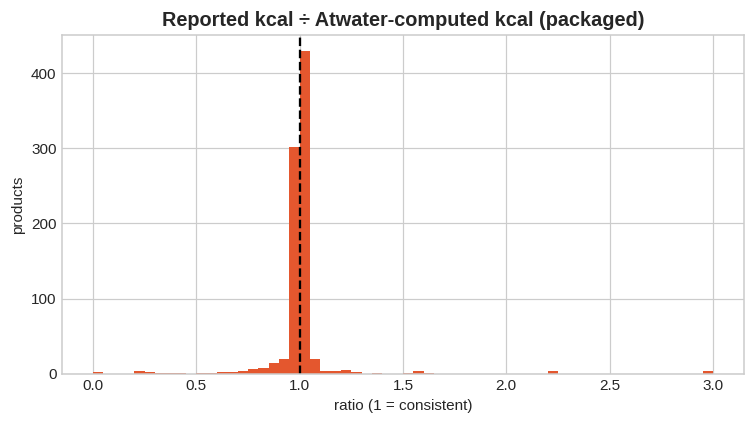

Share of products within ±20% of Atwater estimate: 93.9%


In [7]:
pkg['kcal_atwater'] = 4 * pkg['Carbohydrates_g'] + 4 * pkg['Proteins_g'] + 9 * pkg['Total_Fat_g']
pkg['energy_ratio'] = pkg['Calories_kcal'] / pkg['kcal_atwater']

kj_mask = pkg['energy_ratio'].between(3.6, 4.8)
print(f'Rows where calories look like kJ: {kj_mask.sum()}')
display(pkg.loc[kj_mask, ['Item name', 'Calories_kcal', 'kcal_atwater', 'energy_ratio']])
pkg.loc[kj_mask, 'Calories_kcal'] = pkg.loc[kj_mask, 'Calories_kcal'] / 4.184

pkg['energy_ratio'] = pkg['Calories_kcal'] / pkg['kcal_atwater']
fig, ax = plt.subplots(figsize=(8, 4))
pkg['energy_ratio'].replace([np.inf, -np.inf], np.nan).clip(0, 3).hist(bins=60, ax=ax, color='#E4572E')
ax.axvline(1, color='k', ls='--')
ax.set(title='Reported kcal ÷ Atwater-computed kcal (packaged)', xlabel='ratio (1 = consistent)', ylabel='products')
plt.show()
print('Share of products within ±20% of Atwater estimate:',
      f"{pkg['energy_ratio'].between(0.8, 1.2).mean():.1%}")

### 2.2 Normalise to per 100 g

In [8]:
factor = 100 / pkg['Serving_Size_g']
for c in nutrient_cols_pkg:
    pkg[c] = pkg[c] * factor
print(f"Rescaled {(pkg['Serving_Size_g'] != 100).sum()} products whose serving size was not 100 g")

# Physical plausibility: nothing can exceed ~900 kcal/100 g or 100 g of a macro per 100 g
macro_sum = pkg[['Carbohydrates_g', 'Proteins_g', 'Total_Fat_g']].sum(axis=1)
implausible = ((pkg['Calories_kcal'] > 900)
               | (pkg[['Carbohydrates_g', 'Proteins_g', 'Total_Fat_g', 'Sugar_g', 'Dietary_Fiber_g']] > 100).any(axis=1)
               | (macro_sum > 105)                                   # carbs+protein+fat can't exceed the food's weight
               | (pkg['Sugar_g'] > pkg['Carbohydrates_g'] + 1))      # sugar is a subset of carbohydrate
print('Physically implausible rows removed:', implausible.sum())
display(pkg.loc[implausible, ['Item name', 'Serving_Size_g', 'Calories_kcal', 'Carbohydrates_g', 'Proteins_g', 'Total_Fat_g', 'Sugar_g', 'Dietary_Fiber_g']])
pkg = pkg.loc[~implausible].copy()
pkg[nutrient_cols_pkg].describe().T

Rescaled 72 products whose serving size was not 100 g
Physically implausible rows removed: 32


,Item name,Serving_Size_g,Calories_kcal,Carbohydrates_g,Proteins_g,Total_Fat_g,Sugar_g,Dietary_Fiber_g
25,Britannia Good Day Chunkies Chocochip Cookie,100.00,512.00,64.00,68.00,25.50,31.50,0.00
69,Britannia Good Day Chunkies Coconut Cookies,100.00,575.00,532.80,6.20,37.20,28.00,0.00
110,Bloody Bubbly Cream Soda,100.00,18.00,2.60,0.21,0.01,4.40,0.00
113,Bloody Bubbly Litchi Soda,100.00,18.00,2.60,0.21,0.01,4.40,0.00
116,Bloody Bubbly Lemon Soda,100.00,18.00,2.60,0.21,0.01,4.40,0.00
150,No filter 100% juice strawberry,100.00,46.00,11.50,0.00,0.00,15.00,0.00
220,Tata Cold Coffee Belgian Chocolate Iced Coffee...,100.00,31.00,7.00,0.20,4.80,18.80,0.00
273,Let's Try Pepper Murukku Sticks,100.00,578.00,60.08,10.20,37.20,0.11,0.00
283,Haldiram's Halke Fulke - Salted Potato Chips,100.00,518.27,61.00,6.80,77.50,6.20,6.90
400,Cadbury Bournville Cranberry 50% Dark CHOCOLAT...,100.00,526.00,68.00,6.10,31.60,45.70,0.00


,count,mean,std,min,25%,50%,75%,max
Calories_kcal,819.00,360.79,175.75,0.00,223.71,401.00,504.50,858.94
Carbohydrates_g,819.00,49.36,26.16,0.00,23.58,55.00,68.00,99.90
Proteins_g,818.00,5.82,4.77,0.00,1.98,6.00,7.90,27.10
Total_Fat_g,819.00,15.65,13.54,0.00,2.04,14.50,25.95,80.00
Saturated_Fat_g,817.00,6.99,7.27,0.00,0.20,5.00,11.53,48.00
Trans_Fat_g,817.00,0.11,1.55,0.00,0.00,0.00,0.06,43.50
Sugar_g,815.00,22.72,22.81,0.00,3.74,15.00,34.65,98.00
Sodium_mg,815.00,313.27,658.24,0.00,14.25,120.00,400.50,"9,107.60"
Dietary_Fiber_g,816.00,1.36,3.00,0.00,0.00,0.00,0.93,30.00
Cholesterol_mg,806.00,5.02,17.48,0.00,0.00,0.00,1.08,226.72


## 3. Build a shared schema and food groups

Nine nutrients exist in both datasets. Names are harmonised below.

To compare like with like, both datasets are mapped into shared **Food Groups**. Packaged items already have a `Category`; traditional dishes are classified with ordered keyword rules on the dish name (first match wins).

In [9]:
COMMON = ['Calories_kcal', 'Carbs_g', 'Protein_g', 'Fat_g', 'Sugar_g', 'Fibre_g', 'Sodium_mg', 'Calcium_mg', 'Iron_mg']

pkg_std = pkg.rename(columns={'Item name': 'Name', 'Carbohydrates_g': 'Carbs_g', 'Proteins_g': 'Protein_g',
                              'Total_Fat_g': 'Fat_g', 'Dietary_Fiber_g': 'Fibre_g'})
trad_std = trad_raw.rename(columns={'Dish Name': 'Name', 'Calories (kcal)': 'Calories_kcal',
                                    'Carbohydrates (g)': 'Carbs_g', 'Protein (g)': 'Protein_g', 'Fats (g)': 'Fat_g',
                                    'Free Sugar (g)': 'Sugar_g', 'Fibre (g)': 'Fibre_g', 'Sodium (mg)': 'Sodium_mg',
                                    'Calcium (mg)': 'Calcium_mg', 'Iron (mg)': 'Iron_mg'})

PKG_GROUP = {'JUICE': 'Beverages', 'CHOCOLATE': 'Sweets & Desserts', 'SWEETS': 'Sweets & Desserts',
             'ICE CREAM': 'Sweets & Desserts', 'BISCUIT': 'Biscuits & Bakery', 'CAKE': 'Biscuits & Bakery',
             'WAFER': 'Biscuits & Bakery', 'WAFFLE': 'Biscuits & Bakery', 'SNACKS': 'Snacks',
             'SAUCE': 'Sauces & Condiments', 'SPREAD': 'Sauces & Condiments',
             'INSTANT FOOD': 'Meals', 'DAIRY': 'Dairy'}
pkg_std['Food_Group'] = pkg_std['Category'].map(PKG_GROUP)

# Ordered rules: first matching pattern decides the group
TRAD_RULES = [
    ('Meals', r'soup|consomme|sandwich|stock\b|curry|pulao|biryani|biriyani|khichdi|khichri|\bdal\b|rasam(?! powder)|sambar(?! powder)'),
    ('Sauces & Condiments', r'chutney|pickle|achaar|achar|sauce|jam\b|marmalade|murabba|preserve|dressing|mayonnaise|\bdip\b|icing|frosting|masala$|masala\)|powder|panch phoran|spice|filling|baghar|tadka'),
    ('Beverages', r'\btea\b|coffee|milkshake|shake|sharbat|squash|punch|lassi|drink|juice|\bpani\b|(?<!cress )water|cocoa|nog|mintade|lemonade|thandai|kanji|smoothie|hot chocolate'),
    ('Biscuits & Bakery', r'biscuit|cookie|(?<!pan)cake|pastry|pastries|muffin|tart|\bpie\b|puff|choux|brownie|bread man|flan|cream horn'),
    ('Sweets & Desserts', r'kheer|halwa|burfi|barfi|ladoo|laddoo|ice cream|pudding|custard|mousse|\bfool\b|sunday|sundae|alaska|bavarian|gunjia|jamun|rasgulla|chum chum|rajbogh|mal pua|payasam|shrikhand|chikki|candy|sweet(?! corn| potato| and sour|.*salty)|meetha|milk cake|jalebi|sandesh|putharekulu|triffle|trifle|snowball|(?<!cheese )(?<!potato )souffle'),
    ('Snacks', r'pakora|pakoda|samosa|chips|\bsev\b|mathri|cutlet|dhokla|khaman|khakhra|chaat|vada|kachori|namkeen|bhujia|chivda|chiwda|murmura|muthia|tikka|shaslik|\b65\b|patties|burger|nuggets|popcorn|roasted channa|fritter'),
    ('Dairy', r'raita|yogurt|curd|dahi|paneer(?!.*(pulao|kheer|tikka|cutlet))|cheese(?!.*(pancake|pie|omel|souffle))'),
]
def classify_dish(name):
    n = name.lower()
    for group, pat in TRAD_RULES:
        if re.search(pat, n):
            return group
    return 'Meals'   # curries, dals, rice, breads, soups, sandwiches, egg/meat dishes, etc.

trad_std['Food_Group'] = trad_std['Name'].map(classify_dish)

# Sodium sanity check for traditional dishes: ~40 soups/pulaos show 3,000-14,000 mg sodium per 100 g,
# i.e. 7-35 g of salt per 100 g of soup - saltier than seawater (~1,100 mg/100 g). These look like data errors,
# so sodium is blanked for them. Genuinely salty condiments (pickles, masala/spice mixes) are kept.
salty_ok = trad_std['Name'].str.contains(r'pickle|achaar|achar|masala|powder', case=False)
bad_na = (trad_std['Sodium_mg'] > 3000) & ~salty_ok
print(f'Traditional dishes with implausible sodium set to NaN: {bad_na.sum()}')
print('  e.g.', ', '.join(trad_std.loc[bad_na, 'Name'].head(8)))
trad_std.loc[bad_na, 'Sodium_mg'] = np.nan

trad_std['Category'] = trad_std['Food_Group']

print('Traditional dishes per group:')
print(trad_std['Food_Group'].value_counts(), '\n')
for g in trad_std['Food_Group'].unique():
    print(f'{g:28s} e.g. ', ', '.join(trad_std.loc[trad_std.Food_Group == g, 'Name'].sample(4, random_state=1).str[:30]))

Traditional dishes with implausible sodium set to NaN: 35
  e.g. Clear tomato soup (Tamatar ka soup), Lentil soup, Chicken consomme (Clear chicken soup), Cream of tomato soup, Cream of green peas soup, Cream of spinach soup, Cream of mixed vegetable soup, Cream of mushroom soup
Traditional dishes per group:
Food_Group
Meals                  510
Sweets & Desserts      123
Sauces & Condiments    116
Biscuits & Bakery      104
Snacks                  66
Beverages               50
Dairy                   45
Name: count, dtype: int64 

Beverages                    e.g.  Coffee ice cream, Apple and honey sorbet (Seb au, Semolina milk drink (Thari kan, Apple oats chia seed smoothie
Meals                        e.g.  Chicken consomme (Clear chicke, Peas brinjal bhartha (Matar ba, Mutton pulao, Soyabean tikki
Sweets & Desserts            e.g.  Coconut burfi (Nariyal ki burf, Lotus seed halwa (Kamal gattay, Caramel custard (baked), Wheat flour and nuts ladoos (A
Snacks                       e.g.

## 4. Combine the datasets

In [10]:
keep = ['Name', 'Category', 'Food_Group'] + COMMON
combined = pd.concat([
    pkg_std[keep + ['Brand_Name']].assign(Source='Packaged'),
    trad_std[keep].assign(Source='Traditional'),
], ignore_index=True)

# Derived metrics
combined['Energy_from_Carbs_%'] = 4 * combined['Carbs_g'] / combined['Calories_kcal'] * 100
combined['Energy_from_Protein_%'] = 4 * combined['Protein_g'] / combined['Calories_kcal'] * 100
combined['Energy_from_Fat_%'] = 9 * combined['Fat_g'] / combined['Calories_kcal'] * 100
combined['Protein_per_100kcal'] = combined['Protein_g'] / combined['Calories_kcal'] * 100
combined['Salt_g'] = combined['Sodium_mg'] * 2.5 / 1000
for c in ['Energy_from_Carbs_%', 'Energy_from_Protein_%', 'Energy_from_Fat_%', 'Protein_per_100kcal']:
    combined.loc[combined['Calories_kcal'] < 5, c] = np.nan   # avoid division noise for ~0 kcal items

print(combined.shape)
print(combined['Source'].value_counts())
print('\nMissing values in shared nutrients:')
print(combined[COMMON].isna().sum())
combined.sample(6, random_state=7)

(1834, 19)
Source
Traditional    1014
Packaged        820
Name: count, dtype: int64

Missing values in shared nutrients:
Calories_kcal     1
Carbs_g           1
Protein_g         2
Fat_g             1
Sugar_g           5
Fibre_g           4
Sodium_mg        40
Calcium_mg        5
Iron_mg           7
dtype: int64


,Name,Category,Food_Group,Calories_kcal,Carbs_g,Protein_g,Fat_g,Sugar_g,Fibre_g,Sodium_mg,Calcium_mg,Iron_mg,Brand_Name,Source,Energy_from_Carbs_%,Energy_from_Protein_%,Energy_from_Fat_%,Protein_per_100kcal,Salt_g
179,Mountain Dew Lemon Soft Drink,JUICE,Beverages,49.00,12.30,0.00,0.00,12.30,0.00,8.00,0.00,0.00,MOUMTAIN DEW,Packaged,100.41,0.00,0.00,0.00,0.02
1771,Glace icing,Sauces & Condiments,Sauces & Condiments,323.51,86.31,0.01,0.01,85.35,0.00,9.88,1.95,0.41,NaN,Traditional,106.72,0.01,0.03,0.00,0.02
1260,Gingo,Meals,Meals,48.02,12.42,0.14,0.06,12.08,0.17,21.50,6.33,0.21,NaN,Traditional,103.46,1.17,1.12,0.29,0.05
1583,Chickpea flour cookies (Sweet besan rounds/coo...,Biscuits & Bakery,Biscuits & Bakery,207.01,39.64,4.29,3.42,30.66,2.56,22.29,54.95,2.16,NaN,Traditional,76.60,8.29,14.87,2.07,0.06
377,Amul Dark CHOCOLATE BAR,CHOCOLATE,Sweets & Desserts,521.00,51.40,6.40,33.10,43.00,0.00,38.00,0.00,0.00,AMUL,Packaged,39.46,4.91,57.18,1.23,0.10
653,Golden Prize Tuna Spread In Mayonnaise,INSTANT FOOD,Meals,83.72,7.44,10.23,1.40,2.33,0.00,581.40,0.00,0.00,GOLDEN PRICE,Packaged,35.56,48.89,15.00,12.22,1.45


In [11]:
# Optional: save the combined table
combined.to_csv('combined_indian_foods.csv', index=False)

## 5. Head-to-head: packaged vs traditional

In [12]:
summary = combined.groupby('Source')[COMMON].median().T
summary['Packaged ÷ Traditional'] = summary['Packaged'] / summary['Traditional']
print('Median per 100 g')
summary

Median per 100 g


Source,Packaged,Traditional,Packaged ÷ Traditional
Calories_kcal,401.00,174.92,2.29
Carbs_g,55.00,11.93,4.61
Protein_g,6.00,3.99,1.50
Fat_g,14.50,9.09,1.59
Sugar_g,15.00,2.78,5.40
Fibre_g,0.00,1.33,0.00
Sodium_mg,120.00,97.38,1.23
Calcium_mg,0.00,40.68,0.00
Iron_mg,0.00,0.83,0.00


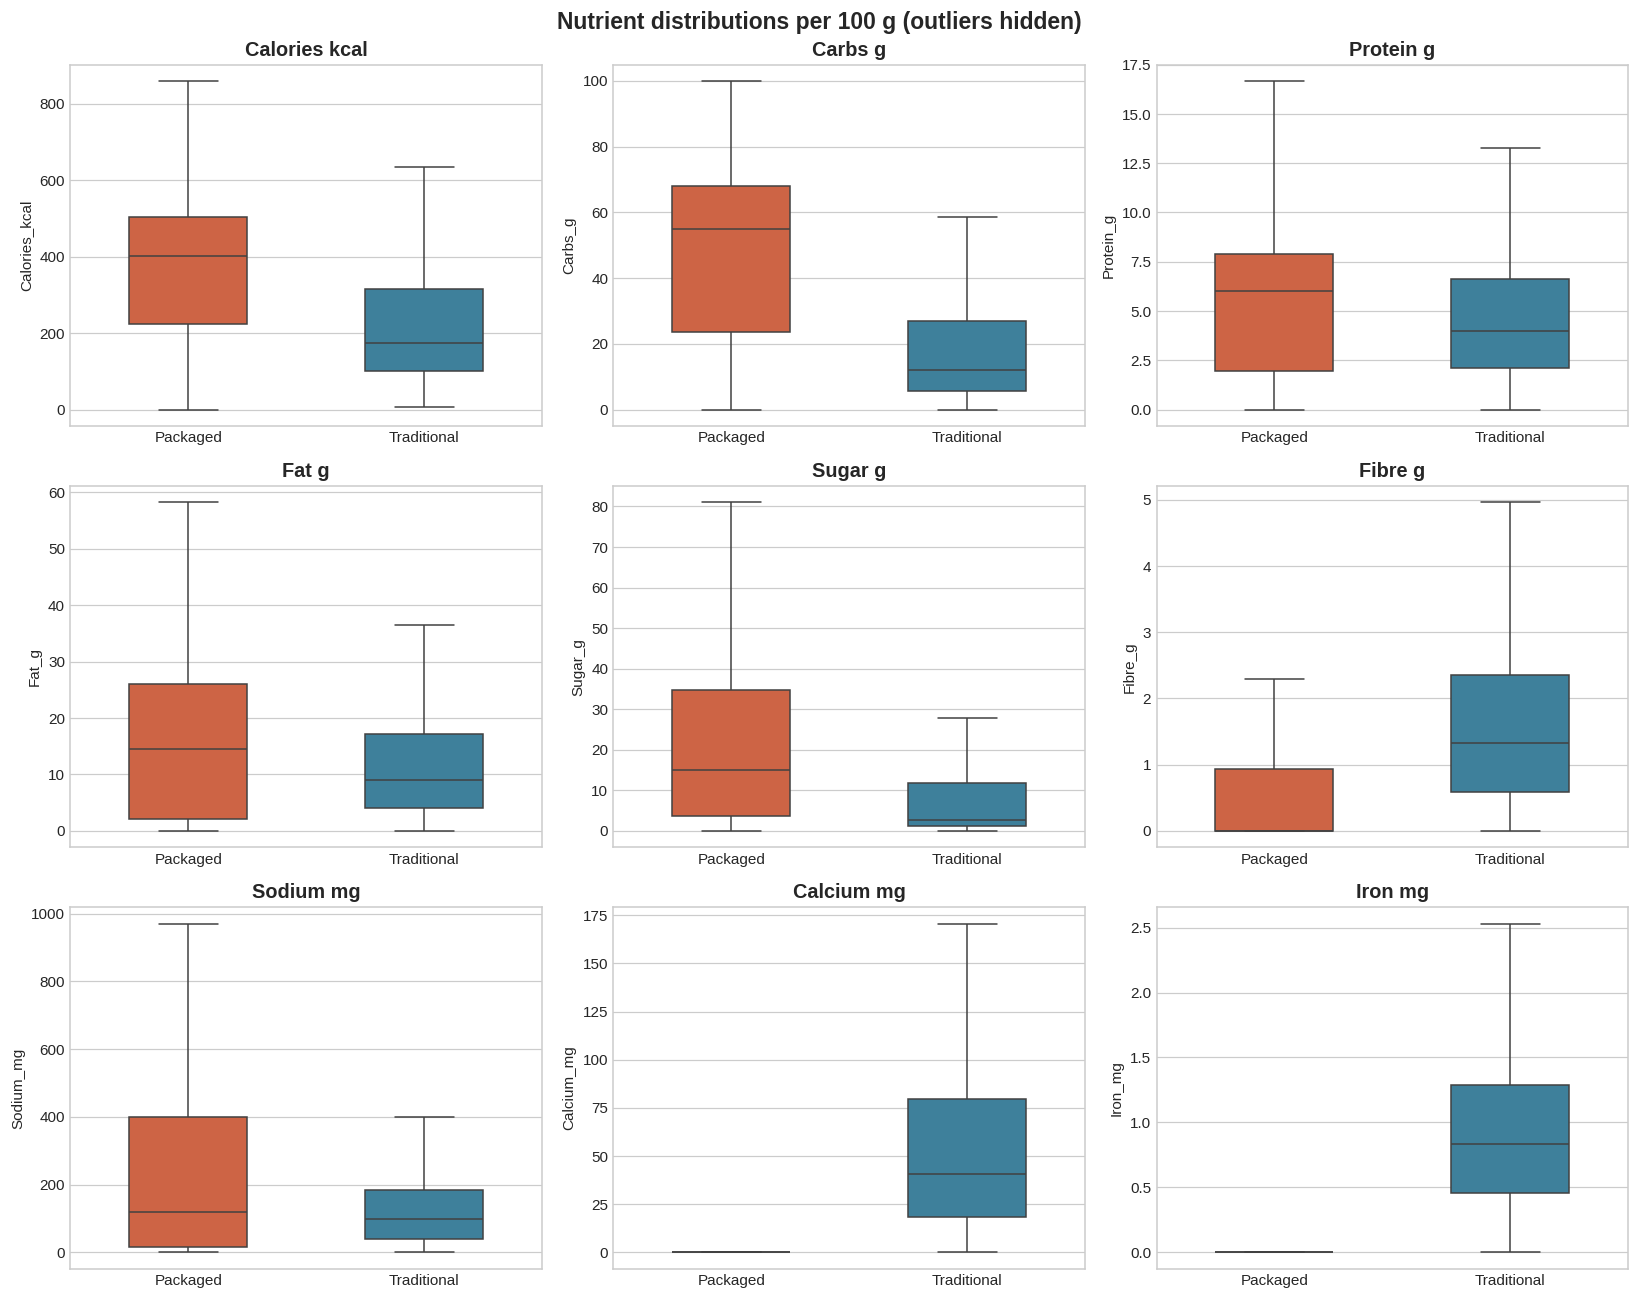

In [13]:
fig, axes = plt.subplots(3, 3, figsize=(15, 12))
for ax, col in zip(axes.flat, COMMON):
    sns.boxplot(data=combined, x='Source', y=col, palette=PALETTE, ax=ax, showfliers=False, width=0.5)
    ax.set_title(col.replace('_', ' '))
    ax.set_xlabel('')
fig.suptitle('Nutrient distributions per 100 g (outliers hidden)', fontsize=15, fontweight='bold')
plt.tight_layout()
plt.show()

### 5.1 Are the differences statistically significant?

Nutrient data is heavily skewed, so a **Mann-Whitney U** test (non-parametric) is used, with the rank-biserial correlation as the effect size (−1…+1; positive = packaged higher).

In [14]:
rows = []
for col in COMMON:
    a = combined.loc[combined.Source == 'Packaged', col].dropna()
    b = combined.loc[combined.Source == 'Traditional', col].dropna()
    u, p = stats.mannwhitneyu(a, b, alternative='two-sided')
    rbc = 2 * u / (len(a) * len(b)) - 1
    rows.append({'Nutrient': col, 'Packaged median': a.median(), 'Traditional median': b.median(),
                 'p-value': p, 'Effect size (r)': rbc,
                 'Magnitude': pd.cut([abs(rbc)], [-0.01, 0.1, 0.3, 0.5, 1.0], labels=['negligible', 'small', 'medium', 'large'])[0]})
tests = pd.DataFrame(rows).set_index('Nutrient')
tests['p-value'] = tests['p-value'].map(lambda p: f'{p:.1e}')
tests

,Packaged median,Traditional median,p-value,Effect size (r),Magnitude
Nutrient,,,,,
Calories_kcal,401.00,174.92,7.0e-48,0.39,medium
Carbs_g,55.00,11.93,3.3e-133,0.67,large
Protein_g,6.00,3.99,1.7e-05,0.12,small
Fat_g,14.50,9.09,3.0e-02,0.06,negligible
Sugar_g,15.00,2.78,9.5e-48,0.39,medium
Fibre_g,0.00,1.33,2.9e-84,-0.52,large
Sodium_mg,120.00,97.38,4.3e-02,0.06,negligible
Calcium_mg,0.00,40.68,5.7e-227,-0.85,large
Iron_mg,0.00,0.83,2.3e-250,-0.89,large


**Caution on fibre, calcium and iron:** Indian packaged-food labels are only required to declare energy, protein, carbs, sugar, fat and sodium. Fibre, calcium and iron are often left blank or entered as 0, so a "0" here usually means *not declared*, not *absent*. The check below quantifies this; those three comparisons should be read as "packaged labels rarely report these", not as proof the foods contain none.

In [15]:
zero_share = combined.groupby('Source')[['Fibre_g', 'Calcium_mg', 'Iron_mg', 'Sugar_g', 'Sodium_mg']].apply(lambda d: (d == 0).mean() * 100).round(1)
print('% of items reporting exactly 0')
zero_share

% of items reporting exactly 0


,Fibre_g,Calcium_mg,Iron_mg,Sugar_g,Sodium_mg
Source,,,,,
Packaged,70.60,87.40,92.20,8.20,15.60
Traditional,5.00,0.10,0.10,0.30,0.10


### 5.2 Where do the calories come from?

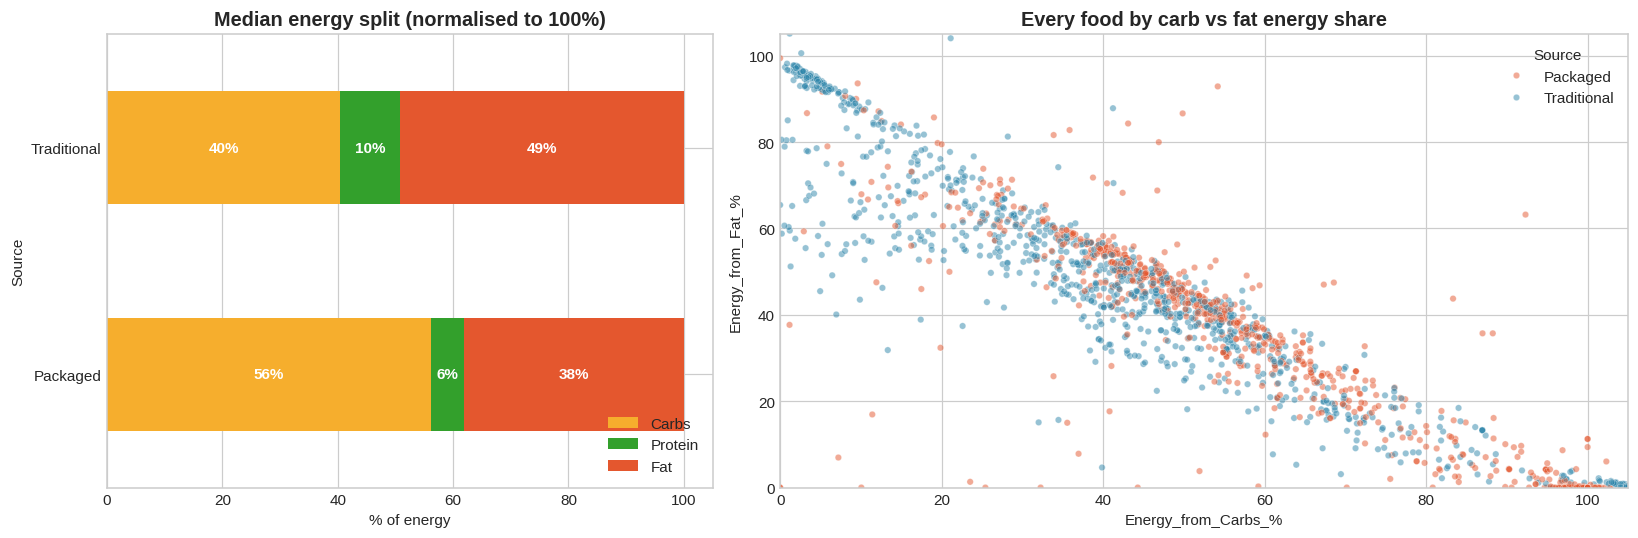

In [16]:
energy = combined.groupby('Source')[['Energy_from_Carbs_%', 'Energy_from_Protein_%', 'Energy_from_Fat_%']].median()
energy = energy.div(energy.sum(axis=1), axis=0) * 100

fig, axes = plt.subplots(1, 2, figsize=(15, 5), gridspec_kw={'width_ratios': [1, 1.4]})
energy.plot(kind='barh', stacked=True, ax=axes[0], color=['#F6AE2D', '#33A02C', '#E4572E'])
axes[0].set(title='Median energy split (normalised to 100%)', xlabel='% of energy')
axes[0].legend(['Carbs', 'Protein', 'Fat'], loc='lower right')
for i, (_, r) in enumerate(energy.iterrows()):
    left = 0
    for v in r:
        axes[0].text(left + v / 2, i, f'{v:.0f}%', ha='center', va='center', color='white', fontweight='bold')
        left += v

sns.scatterplot(data=combined.sample(frac=1, random_state=0), x='Energy_from_Carbs_%', y='Energy_from_Fat_%',
                hue='Source', palette=PALETTE, alpha=0.5, s=18, ax=axes[1])
axes[1].set(xlim=(0, 105), ylim=(0, 105), title='Every food by carb vs fat energy share')
plt.tight_layout()
plt.show()

## 6. Like-for-like: comparison within food groups

In [17]:
grp = combined.groupby(['Food_Group', 'Source']).agg(
    n=('Name', 'size'),
    kcal=('Calories_kcal', 'median'),
    sugar=('Sugar_g', 'median'),
    fat=('Fat_g', 'median'),
    protein=('Protein_g', 'median'),
    fibre=('Fibre_g', 'median'),
    sodium=('Sodium_mg', 'median'),
).round(1)
grp

n   kcal  sugar   fat  protein  fibre  sodium
Food_Group          Source                                                      
Beverages           Packaged     113  50.00  11.50  0.00     0.00   0.00   22.20
                    Traditional   50  67.30   8.40  1.10     1.10   0.20   15.40
Biscuits & Bakery   Packaged     147 468.30  24.60 20.00     7.00   0.00  197.00
                    Traditional  104 334.60  21.70 15.10     5.60   1.10  117.90
Dairy               Packaged      10 199.00   3.10 12.20     6.40   0.00   47.50
                    Traditional   45  95.10   4.90  4.80     4.10   1.20  166.90
Meals               Packaged     128 333.60   2.70  7.40     7.90   0.00  384.00
                    Traditional  510 146.60   1.60  8.60     4.30   1.70  115.60
Sauces & Condiments Packaged      35 279.30   9.10  3.60     0.80   0.00  579.50
                    Traditional  116 169.50   4.60  7.30     2.10   1.20  160.00
Snacks              Packaged     135 522.00   2.50 28.90     7.30   0.00  636.00
                    Traditional   66 577.20   0.90 58.40     2.80   1.20   86.40
Sweets & Desserts   Packaged     252 427.00  45.90 15.50     4.60   0.00   40.60
                    Traditional  123 183.50  14.60  9.70     4.50   0.60   27.10

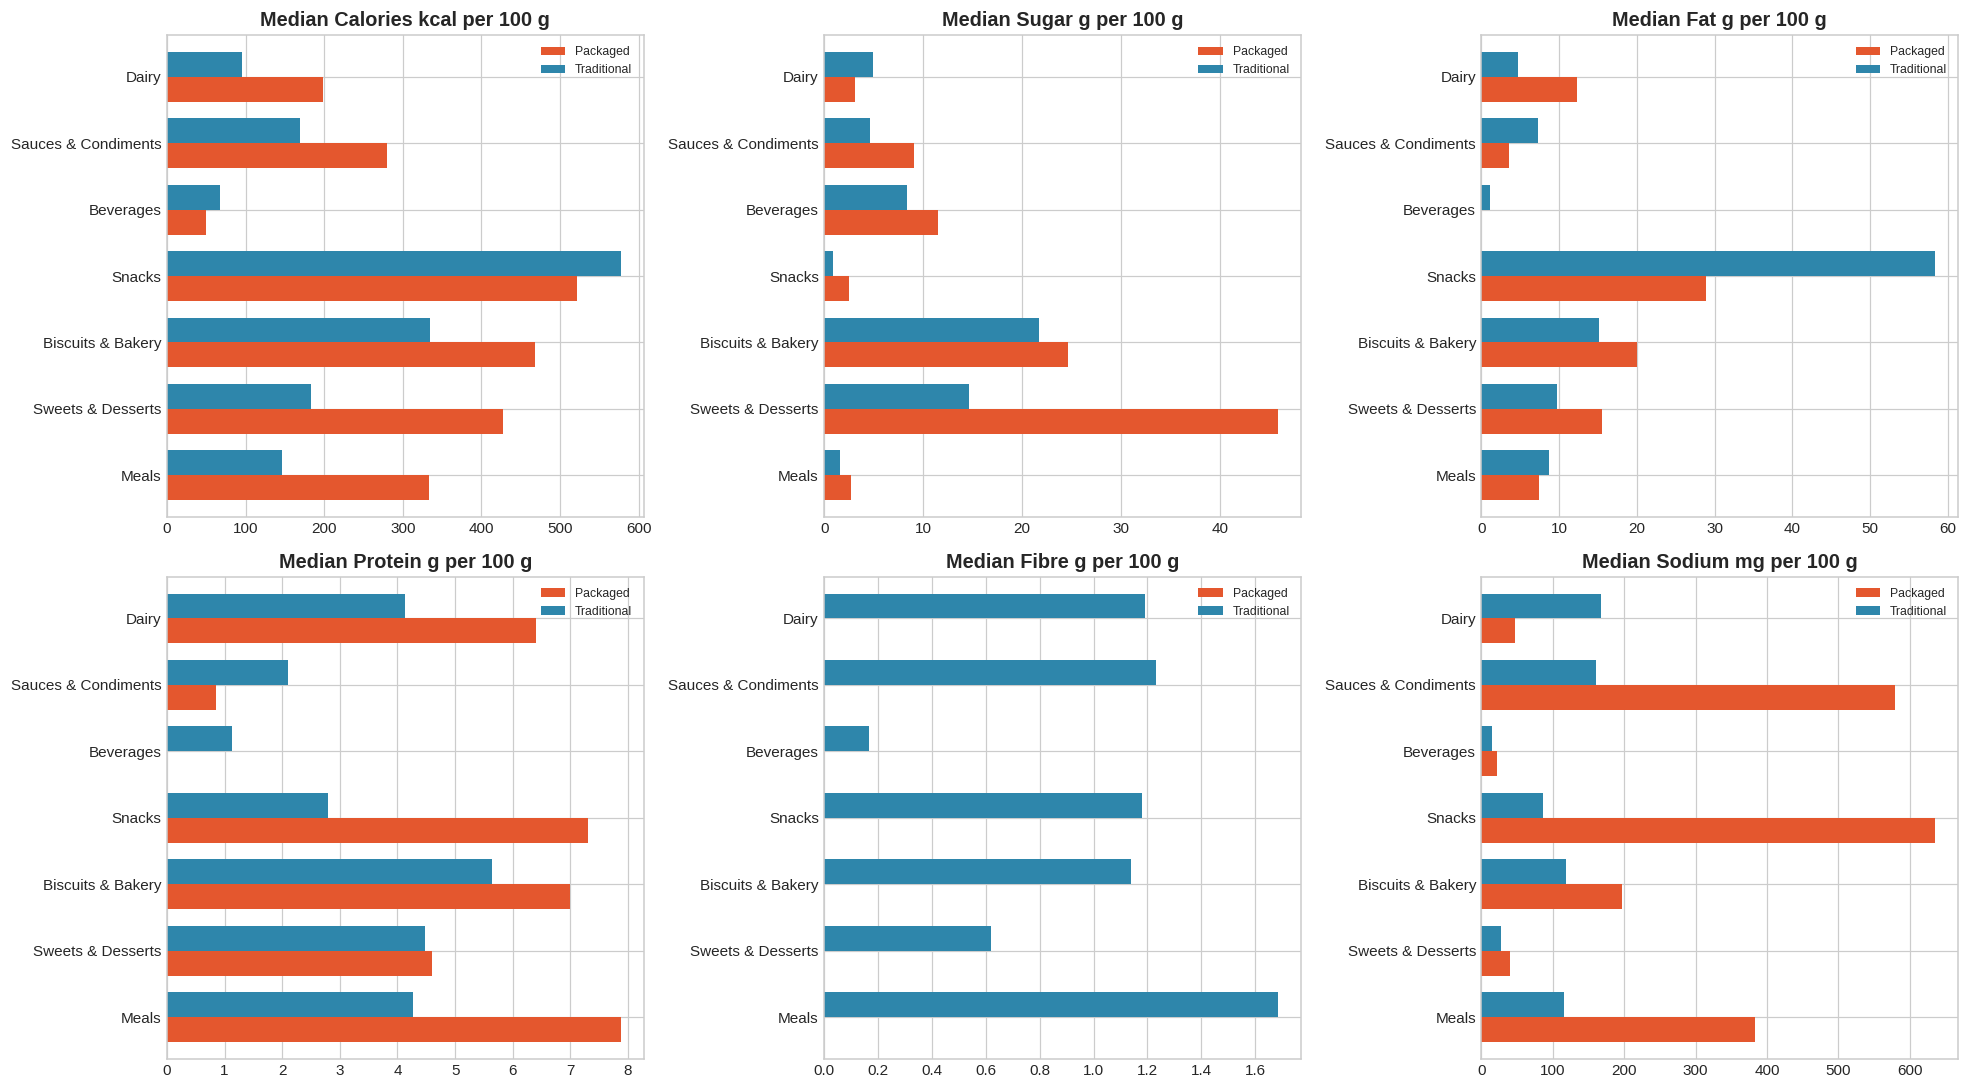

In [18]:
metrics = ['Calories_kcal', 'Sugar_g', 'Fat_g', 'Protein_g', 'Fibre_g', 'Sodium_mg']
order = combined['Food_Group'].value_counts().index
fig, axes = plt.subplots(2, 3, figsize=(18, 10))
for ax, m in zip(axes.flat, metrics):
    d = combined.groupby(['Food_Group', 'Source'])[m].median().unstack()
    d.loc[order].plot(kind='barh', ax=ax, color=[PALETTE['Packaged'], PALETTE['Traditional']], width=0.75)
    ax.set_title(f'Median {m.replace("_", " ")} per 100 g')
    ax.set_ylabel('')
    ax.legend(fontsize=8)
plt.tight_layout()
plt.show()

## 7. Nutrition "traffic-light" flags

Using the UK Food Standards Agency front-of-pack thresholds (per 100 g, foods): **High** fat > 17.5 g, sugar > 22.5 g, salt > 1.5 g (≈ sodium > 600 mg). These are a widely used reference; India's FSSAI has proposed similar "high in fat/sugar/salt" labelling.

,High_Fat,High_Sugar,High_Salt,≥1 red flag %,≥2 red flags %
Source,,,,,
Packaged,43.40,38.40,17.00,69.10,29.40
Traditional,24.40,14.10,2.60,36.10,4.90


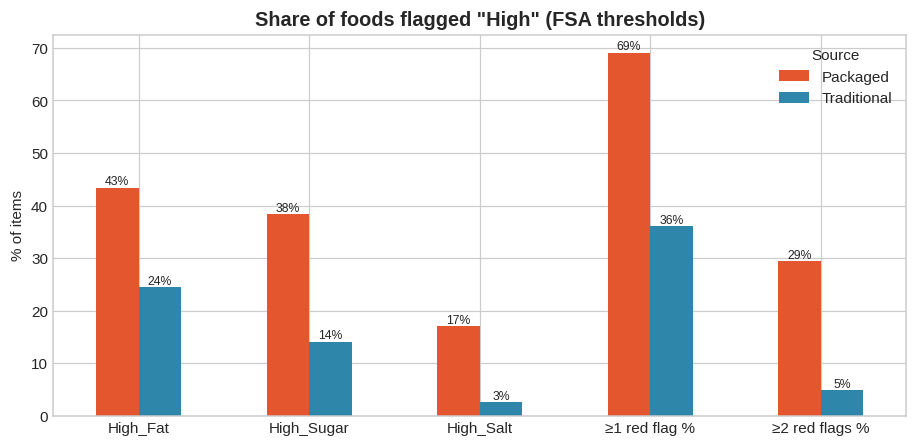

In [19]:
combined['High_Fat'] = combined['Fat_g'] > 17.5
combined['High_Sugar'] = combined['Sugar_g'] > 22.5
combined['High_Salt'] = combined['Salt_g'] > 1.5
combined['High_Flags'] = combined[['High_Fat', 'High_Sugar', 'High_Salt']].sum(axis=1)

flags = combined.groupby('Source')[['High_Fat', 'High_Sugar', 'High_Salt']].mean().mul(100).round(1)
flags['≥1 red flag %'] = combined.groupby('Source')['High_Flags'].apply(lambda s: (s >= 1).mean() * 100).round(1)
flags['≥2 red flags %'] = combined.groupby('Source')['High_Flags'].apply(lambda s: (s >= 2).mean() * 100).round(1)
display(flags)

ax = flags.T.plot(kind='bar', figsize=(10, 4.5), color=[PALETTE['Packaged'], PALETTE['Traditional']], rot=0)
ax.set(title='Share of foods flagged "High" (FSA thresholds)', ylabel='% of items')
for cont in ax.containers:
    ax.bar_label(cont, fmt='%.0f%%', fontsize=8)
plt.show()

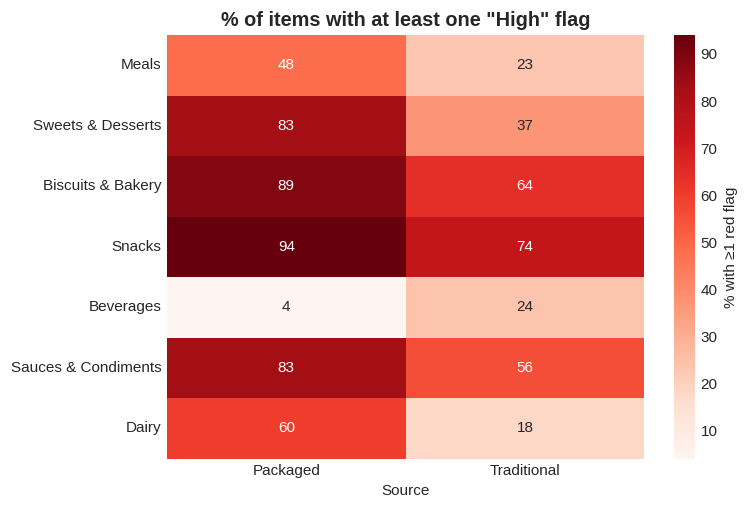

In [20]:
fg_flags = combined.groupby(['Food_Group', 'Source'])['High_Flags'].apply(lambda s: (s >= 1).mean() * 100).unstack().round(0)
plt.figure(figsize=(7, 5))
sns.heatmap(fg_flags.loc[order], annot=True, fmt='.0f', cmap='Reds', cbar_kws={'label': '% with ≥1 red flag'})
plt.title('% of items with at least one "High" flag')
plt.ylabel('')
plt.show()

## 8. Top-10 extremes across the combined data

In [21]:
def top(col, n=10, asc=False):
    return (combined.sort_values(col, ascending=asc)
            .head(n)[['Name', 'Source', 'Food_Group', col]]
            .assign(Name=lambda d: d['Name'].str[:55])
            .reset_index(drop=True))

print('Highest sugar per 100 g');           display(top('Sugar_g'))
print('Highest sodium per 100 g (after removing implausible values)');          display(top('Sodium_mg'))
print('Highest protein per 100 g');         display(top('Protein_g'))
print('Highest fibre per 100 g');           display(top('Fibre_g'))

Highest sugar per 100 g


,Name,Source,Food_Group,Sugar_g
0,Simpkins Travel Sweets - Mixed Mint,Packaged,Sweets & Desserts,98.00
1,Simpkins Travel Sweets - Mixed Fruit,Packaged,Sweets & Desserts,98.00
2,Parle Kaccha Mango Bite Candy,Packaged,Sweets & Desserts,97.30
3,CandyVille Froot Fab Flavoured Candy - Blueberry,Packaged,Sweets & Desserts,94.56
4,Tic Tac Orange Hard Candy,Packaged,Sweets & Desserts,93.30
5,Weikfield Jelly Crystals Strawberry Flavour Ca...,Packaged,Meals,91.70
6,Tic Tac Candy - Red Apple Treat,Packaged,Sweets & Desserts,91.40
7,Doublemint Peppermint Chewy Mints Tube,Packaged,Sweets & Desserts,91.00
8,Skittles Wildberry Bite-Size Fruit Flavoured C...,Packaged,Sweets & Desserts,90.00
9,Skittles Original Bite-Size Fruit Candy Tube,Packaged,Sweets & Desserts,90.00


Highest sodium per 100 g (after removing implausible values)


,Name,Source,Food_Group,Sodium_mg
0,Chat masala,Traditional,Sauces & Condiments,"11,873.64"
1,Cookd Tandoori Tikka Kit,Packaged,Meals,"9,107.60"
2,Lemon green chilli pickle (Nimboo aur hari mir...,Traditional,Sauces & Condiments,"7,559.38"
3,Priya Lime Pickle In Lime Juice With Garlic,Packaged,Meals,"7,284.00"
4,Knorr Chinese Manchurian Gravy Mix,Packaged,Meals,"6,709.00"
5,"Ching's Secret Dark Soy Sauce, Rich, Brown and...",Packaged,Sauces & Condiments,"6,693.00"
6,Sweet lemon pickle (Neembu ka meetha achaar),Traditional,Sauces & Condiments,"6,415.90"
7,Priya Mango Avakaya Pickle With Garlic,Packaged,Meals,"5,231.00"
8,Wok N Roll Manchurian Masala,Packaged,Meals,"4,340.00"
9,Brinjal pickle (Baingan ka achaar),Traditional,Sauces & Condiments,"3,507.59"


Highest protein per 100 g


,Name,Source,Food_Group,Protein_g
0,Too Yumm! Salted Peanuts | No Palm Oil | Prote...,Packaged,Snacks,27.10
1,bb Gooddiet Roasted Peanuts - Cheese 'N' Onion,Packaged,Snacks,26.05
2,Pintola Classic Peanut Butter - Creamy,Packaged,Sauces & Condiments,26.00
3,Pintola High Protein Oats Dark Chocolate With ...,Packaged,Meals,25.00
4,Mooz Mozzarella & Cheddar Pizza Cheese,Packaged,Dairy,25.00
5,Epigamia Turbo VANILLA CAKE and Caramel Protei...,Packaged,Beverages,25.00
6,Balaji Masala Shing Namkeen,Packaged,Snacks,23.20
7,Crax Double Mazza Roasted Chana Peanuts Namkee...,Packaged,Snacks,22.00
8,Too Yumm! Moong Dal | No Palm Oil | 35% Less S...,Packaged,Snacks,21.70
9,Gun powder chutney,Traditional,Sauces & Condiments,21.55


Highest fibre per 100 g


,Name,Source,Food_Group,Fibre_g
0,Rasam powder (Rasam masala),Traditional,Meals,35.71
1,Garam masala,Traditional,Sauces & Condiments,35.56
2,Sambar powder (Sambar masala),Traditional,Meals,34.56
3,Doritos Dinamita Fiery Lime & Chilli Flavour N...,Packaged,Snacks,30.00
4,Pav bhaji masala,Traditional,Sauces & Condiments,24.30
5,Chat masala,Traditional,Sauces & Condiments,18.62
6,Orion Mango Choco Pie,Packaged,Biscuits & Bakery,18.60
7,Bengal 5 Spice Blend (Panch Phoran),Traditional,Sauces & Condiments,18.40
8,Cookd Tandoori Tikka Kit,Packaged,Meals,17.00
9,Lindt Excellence 90% Cocoa Supreme Dark CHOCOL...,Packaged,Sweets & Desserts,16.67


In [22]:
# Protein density (g protein per 100 kcal) among substantial foods (>=100 kcal/100 g)
dense = combined[combined['Calories_kcal'] >= 100]
print('Best protein per 100 kcal (foods >= 100 kcal/100 g)')
display(dense.sort_values('Protein_per_100kcal', ascending=False).head(10)[['Name', 'Source', 'Food_Group', 'Protein_g', 'Calories_kcal', 'Protein_per_100kcal']].assign(Name=lambda d: d['Name'].str[:55]))

Best protein per 100 kcal (foods >= 100 kcal/100 g)


,Name,Source,Food_Group,Protein_g,Calories_kcal,Protein_per_100kcal
197,Epigamia Turbo VANILLA CAKE and Caramel Protei...,Packaged,Beverages,25.00,136.00,18.38
198,Phab 18g Protein Mango Magic Milkshake,Packaged,Beverages,18.00,125.90,14.30
1052,Fish tikka,Traditional,Snacks,16.00,117.33,13.64
1371,Baked stuffed fish,Traditional,Meals,16.14,121.96,13.23
1669,Lemon chicken,Traditional,Meals,20.20,169.79,11.90
1042,Tandoori chicken,Traditional,Meals,16.26,145.20,11.20
777,Milky Mist Briyas Tofu Paneer,Packaged,Dairy,15.50,139.00,11.15
1759,Brown sauce,Traditional,Sauces & Condiments,11.92,109.18,10.92
1310,Minced meat pancake (with chicken),Traditional,Meals,12.01,116.04,10.35
1664,Afghani chicken,Traditional,Meals,15.66,151.51,10.34


## 9. How nutrients relate to each other

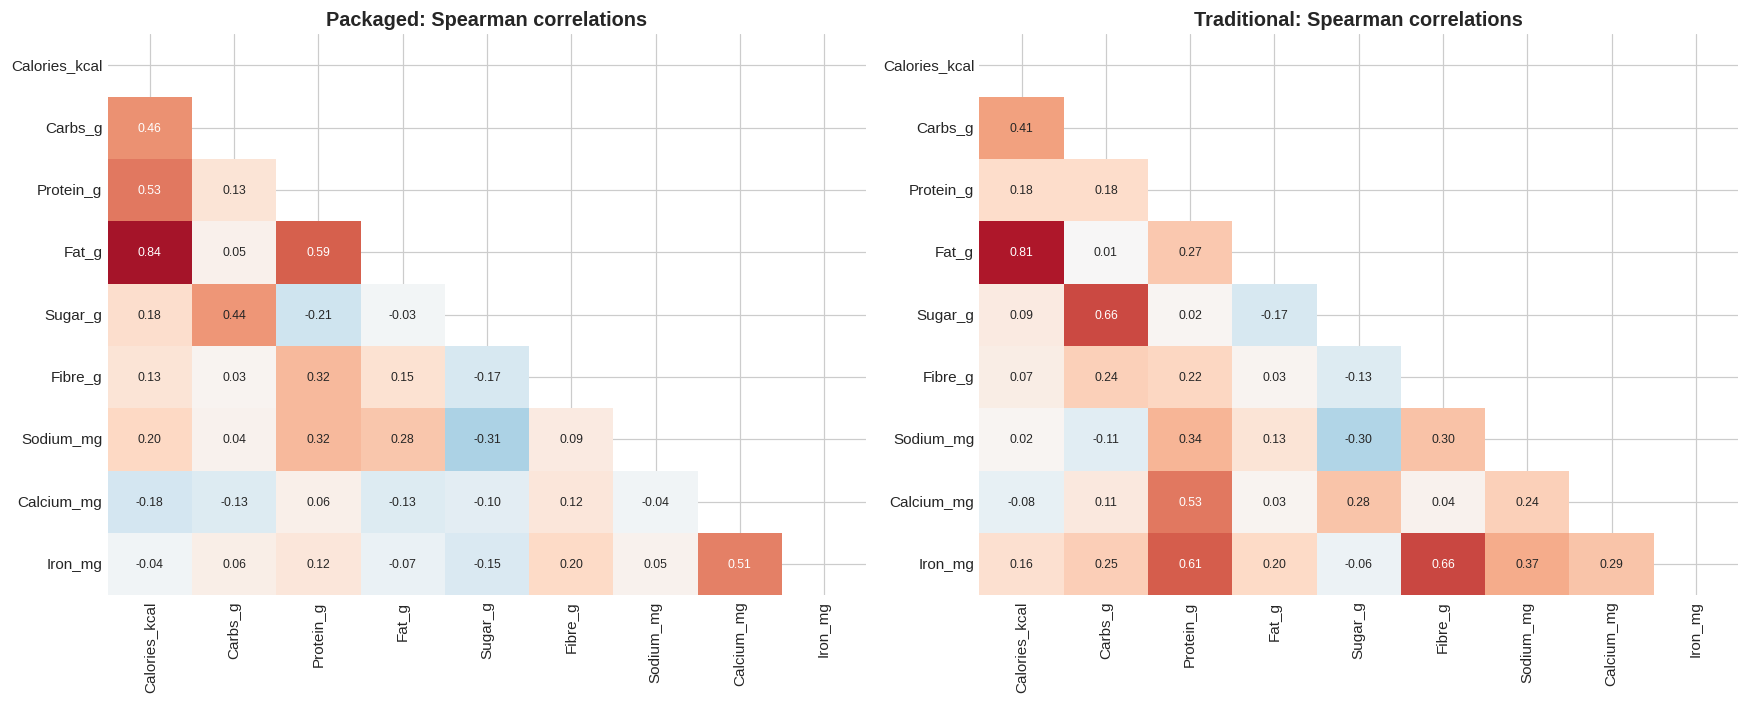

In [23]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6.5))
for ax, src in zip(axes, ['Packaged', 'Traditional']):
    corr = combined.loc[combined.Source == src, COMMON].corr(method='spearman')
    mask = np.triu(np.ones_like(corr, dtype=bool))
    sns.heatmap(corr, mask=mask, annot=True, fmt='.2f', cmap='RdBu_r', center=0, vmin=-1, vmax=1, ax=ax, cbar=False, annot_kws={'size': 8})
    ax.set_title(f'{src}: Spearman correlations')
plt.tight_layout()
plt.show()

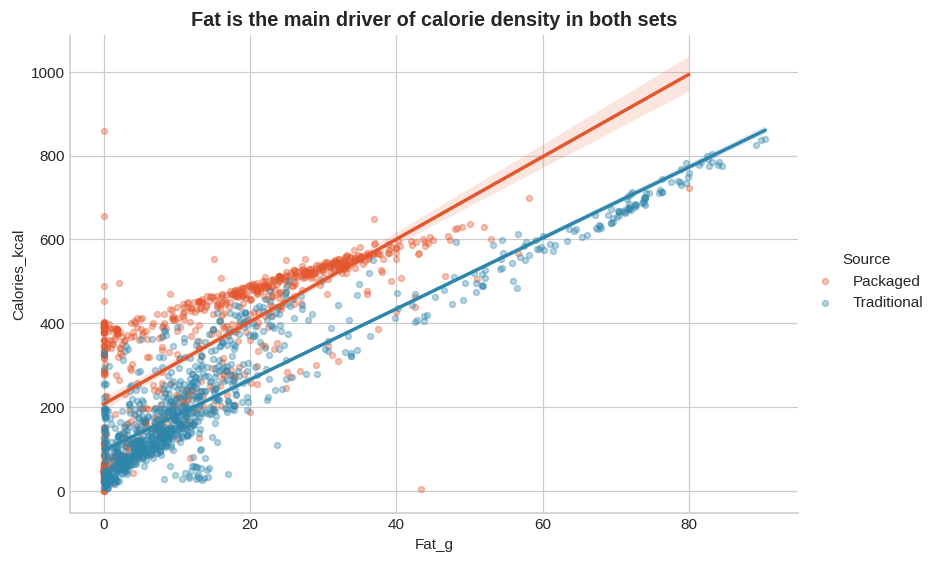

Packaged      r(fat, kcal) = 0.76   r(carbs, kcal) = 0.65
Traditional   r(fat, kcal) = 0.92   r(carbs, kcal) = 0.23


In [24]:
g = sns.lmplot(data=combined, x='Fat_g', y='Calories_kcal', hue='Source', palette=PALETTE,
               scatter_kws={'alpha': 0.35, 's': 15}, height=5, aspect=1.5)
g.ax.set_title('Fat is the main driver of calorie density in both sets')
plt.show()
for src in ['Packaged', 'Traditional']:
    d = combined[combined.Source == src][['Fat_g', 'Carbs_g', 'Calories_kcal']].dropna()
    print(f"{src:12s}  r(fat, kcal) = {d['Fat_g'].corr(d['Calories_kcal']):.2f}   r(carbs, kcal) = {d['Carbs_g'].corr(d['Calories_kcal']):.2f}")

## 10. Do packaged and traditional foods form distinct nutritional clusters?

PCA reduces the 9 standardised nutrients (log-transformed to tame skew) to 2 dimensions; K-Means groups foods by nutrient profile regardless of source.

In [25]:
X = combined[COMMON].dropna()
idx = X.index
X_scaled = StandardScaler().fit_transform(np.log1p(X))

pca = PCA(n_components=2, random_state=0)
pcs = pca.fit_transform(X_scaled)
print('Explained variance:', pca.explained_variance_ratio_.round(3), '→ total', pca.explained_variance_ratio_.sum().round(3))

loadings = pd.DataFrame(pca.components_.T, index=COMMON, columns=['PC1', 'PC2']).round(2)
display(loadings.sort_values('PC1'))

# choose k with the elbow / silhouette
from sklearn.metrics import silhouette_score
scores = {k: silhouette_score(X_scaled, KMeans(k, n_init=10, random_state=0).fit_predict(X_scaled)) for k in range(2, 8)}
print('Silhouette by k:', {k: round(v, 3) for k, v in scores.items()})

Explained variance: [0.285 0.28 ] → total 0.565


,PC1,PC2
Sugar_g,-0.39,0.18
Carbs_g,-0.27,0.43
Calories_kcal,-0.02,0.58
Fat_g,0.20,0.46
Sodium_mg,0.28,0.15
Protein_g,0.29,0.41
Fibre_g,0.40,0.08
Calcium_mg,0.44,-0.18
Iron_mg,0.46,-0.02


Silhouette by k: {2: 0.226, 3: 0.254, 4: 0.234, 5: 0.252, 6: 0.253, 7: 0.244}


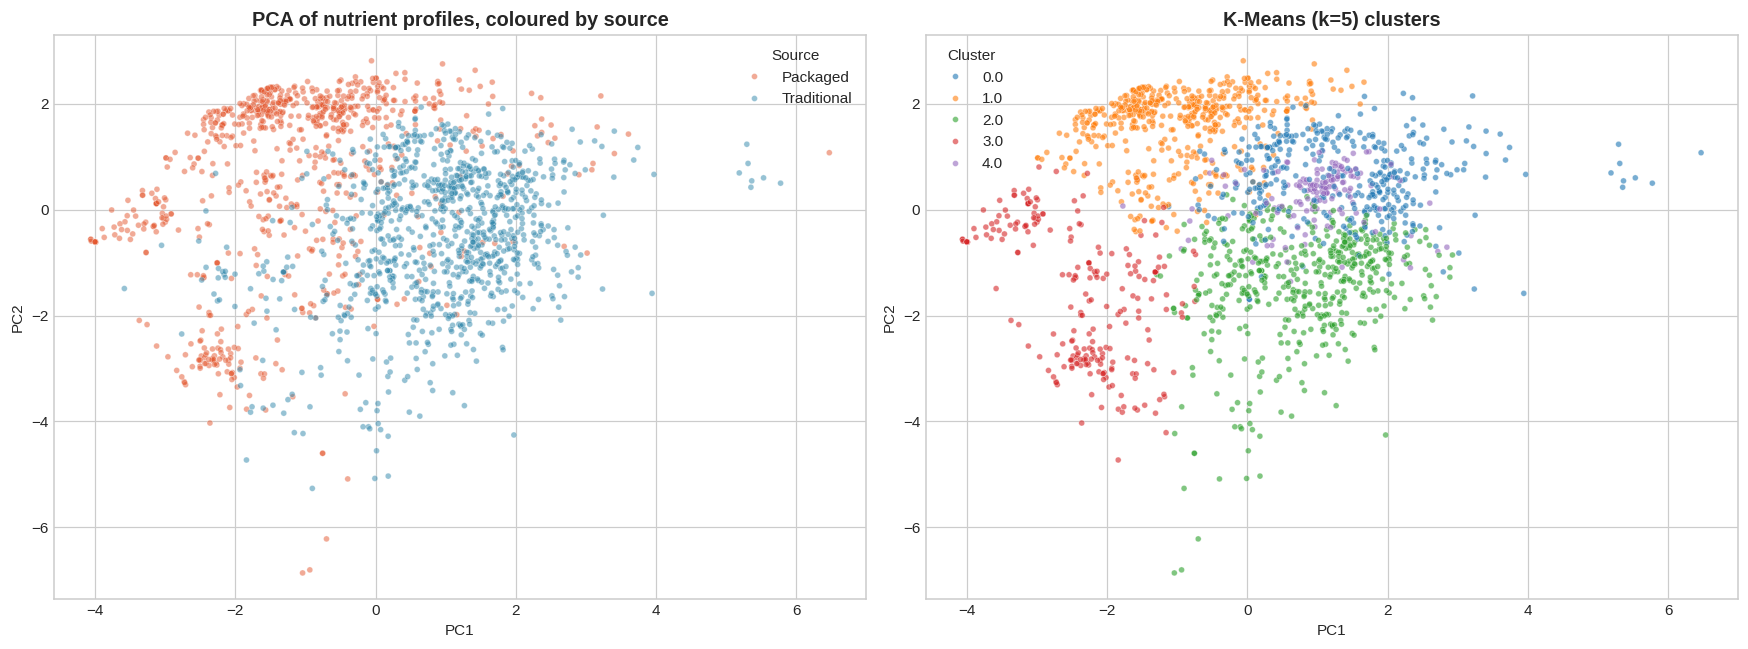

In [26]:
K = 5
km = KMeans(K, n_init=10, random_state=0).fit(X_scaled)
combined.loc[idx, 'Cluster'] = km.labels_
combined.loc[idx, 'PC1'], combined.loc[idx, 'PC2'] = pcs[:, 0], pcs[:, 1]

fig, axes = plt.subplots(1, 2, figsize=(16, 6))
sns.scatterplot(data=combined.loc[idx], x='PC1', y='PC2', hue='Source', palette=PALETTE, alpha=0.5, s=15, ax=axes[0])
axes[0].set_title('PCA of nutrient profiles, coloured by source')
sns.scatterplot(data=combined.loc[idx], x='PC1', y='PC2', hue='Cluster', palette='tab10', alpha=0.6, s=15, ax=axes[1])
axes[1].set_title(f'K-Means (k={K}) clusters')
plt.tight_layout()
plt.show()

In [27]:
prof = combined.loc[idx].groupby('Cluster')[COMMON].median().round(1)
mix = pd.crosstab(combined.loc[idx, 'Cluster'], combined.loc[idx, 'Source'], normalize='index').mul(100).round(0)
mix.columns = [f'% {c}' for c in mix.columns]
prof = prof.join(mix).join(combined.loc[idx].groupby('Cluster').size().rename('n'))
prof['example items'] = [', '.join(combined.loc[idx][combined.loc[idx].Cluster == c]['Name'].sample(3, random_state=2).str[:22]) for c in prof.index]
prof

,Calories_kcal,Carbs_g,Protein_g,Fat_g,Sugar_g,Fibre_g,Sodium_mg,Calcium_mg,Iron_mg,% Packaged,% Traditional,n,example items
Cluster,,,,,,,,,,,,,
0.00,285.80,33.70,6.30,12.40,8.80,2.40,142.50,53.90,1.40,13.00,87.00,381,"Manimark Kamarkat - In, Ritebite Max Protein C..."
1.00,475.00,57.50,7.00,21.60,21.00,0.00,191.40,0.00,0.00,99.00,1.00,515,"Crax Aloo Bhujia Namke, Prasuma Chilli Prawn M..."
2.00,103.50,8.10,3.30,4.90,2.50,1.00,101.60,47.60,0.60,12.00,88.00,501,"Raw turnip with coconu, Urad special dehusked,..."
3.00,130.00,28.30,0.10,0.00,20.00,0.00,12.70,0.00,0.00,75.00,25.00,239,"Tropicana Delight Cran, Raw Pressery Refresher..."
4.00,610.00,5.40,2.10,64.00,0.70,0.90,81.20,13.20,0.50,7.00,93.00,152,"Gram flour and semolin, Mayonnaise without egg..."


## 11. Packaged-only insights: ingredients and price

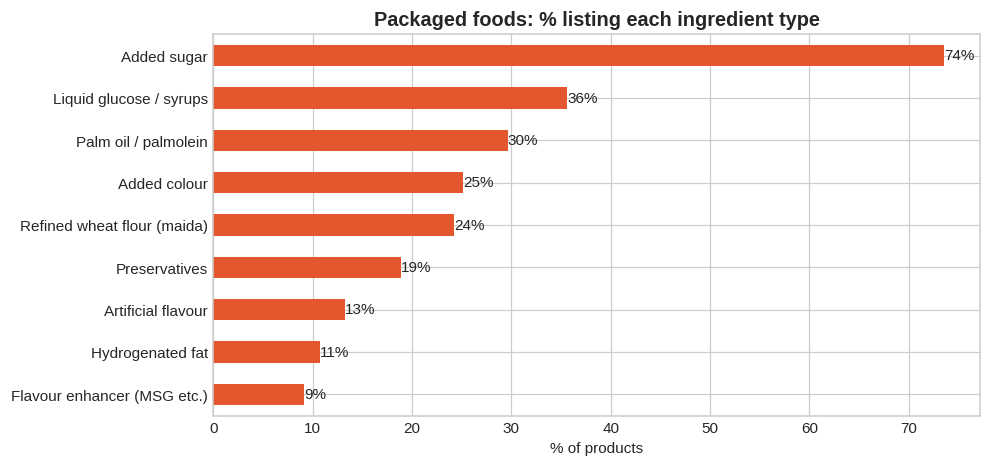

Median number of listed ingredients: 12.0


,Palm oil / palmolein,Refined wheat flour (maida),Hydrogenated fat,Added sugar,Liquid glucose / syrups,Artificial flavour,Added colour,Preservatives,Flavour enhancer (MSG etc.)
Food_Group,,,,,,,,,
Beverages,1.00,0.00,0.00,76.00,10.00,6.00,50.00,43.00,0.00
Biscuits & Bakery,67.00,76.00,27.00,93.00,70.00,41.00,25.00,29.00,1.00
Dairy,0.00,0.00,0.00,20.00,0.00,0.00,20.00,30.00,0.00
Meals,24.00,29.00,5.00,45.00,17.00,4.00,16.00,7.00,21.00
Sauces & Condiments,6.00,0.00,3.00,74.00,0.00,3.00,9.00,57.00,3.00
Snacks,44.00,12.00,1.00,59.00,30.00,1.00,13.00,10.00,33.00
Sweets & Desserts,21.00,13.00,16.00,85.00,46.00,13.00,28.00,7.00,0.00


In [28]:
ing = pkg_std['Ingredients'].fillna('').str.lower()
markers = {
    'Palm oil / palmolein': r'palm',
    'Refined wheat flour (maida)': r'maida|refined wheat flour',
    'Hydrogenated fat': r'hydrogenated',
    'Added sugar': r'\bsugar\b',
    'Liquid glucose / syrups': r'glucose|syrup|dextrose|maltodextrin|fructose',
    'Artificial flavour': r'artificial flavour|artificial flavor',
    'Added colour': r'colour|color|ins 1[0-9]{2}\b',
    'Preservatives': r'preservative|ins 2[0-9]{2}\b|benzoate|sorbate|sulphite',
    'Flavour enhancer (MSG etc.)': r'flavour enhancer|ins 62[0-9]|monosodium',
}
ing_df = pd.DataFrame({k: ing.str.contains(v, regex=True) for k, v in markers.items()})
ing_df['Food_Group'] = pkg_std['Food_Group'].values

overall = ing_df.drop(columns='Food_Group').mean().mul(100).sort_values()
ax = overall.plot(kind='barh', figsize=(9, 4.5), color='#E4572E')
ax.bar_label(ax.containers[0], fmt='%.0f%%')
ax.set(title='Packaged foods: % listing each ingredient type', xlabel='% of products')
plt.show()

pkg_std['n_ingredients'] = pkg_std['Ingredients'].fillna('').str.count(',') + 1
print('Median number of listed ingredients:', pkg_std['n_ingredients'].median())
ing_df.groupby('Food_Group').mean().mul(100).round(0)

In [29]:
# Does palm oil associate with higher saturated fat?
pkg_std['has_palm'] = ing_df['Palm oil / palmolein'].values
print(pkg_std.groupby('has_palm')[['Saturated_Fat_g', 'Fat_g']].median())
a = pkg_std.loc[pkg_std.has_palm, 'Saturated_Fat_g'].dropna()
b = pkg_std.loc[~pkg_std.has_palm, 'Saturated_Fat_g'].dropna()
print('Mann-Whitney p =', f'{stats.mannwhitneyu(a, b).pvalue:.1e}')

          Saturated_Fat_g  Fat_g
has_palm                        
False                2.08   8.00
True                10.50  21.60
Mann-Whitney p = 6.9e-33


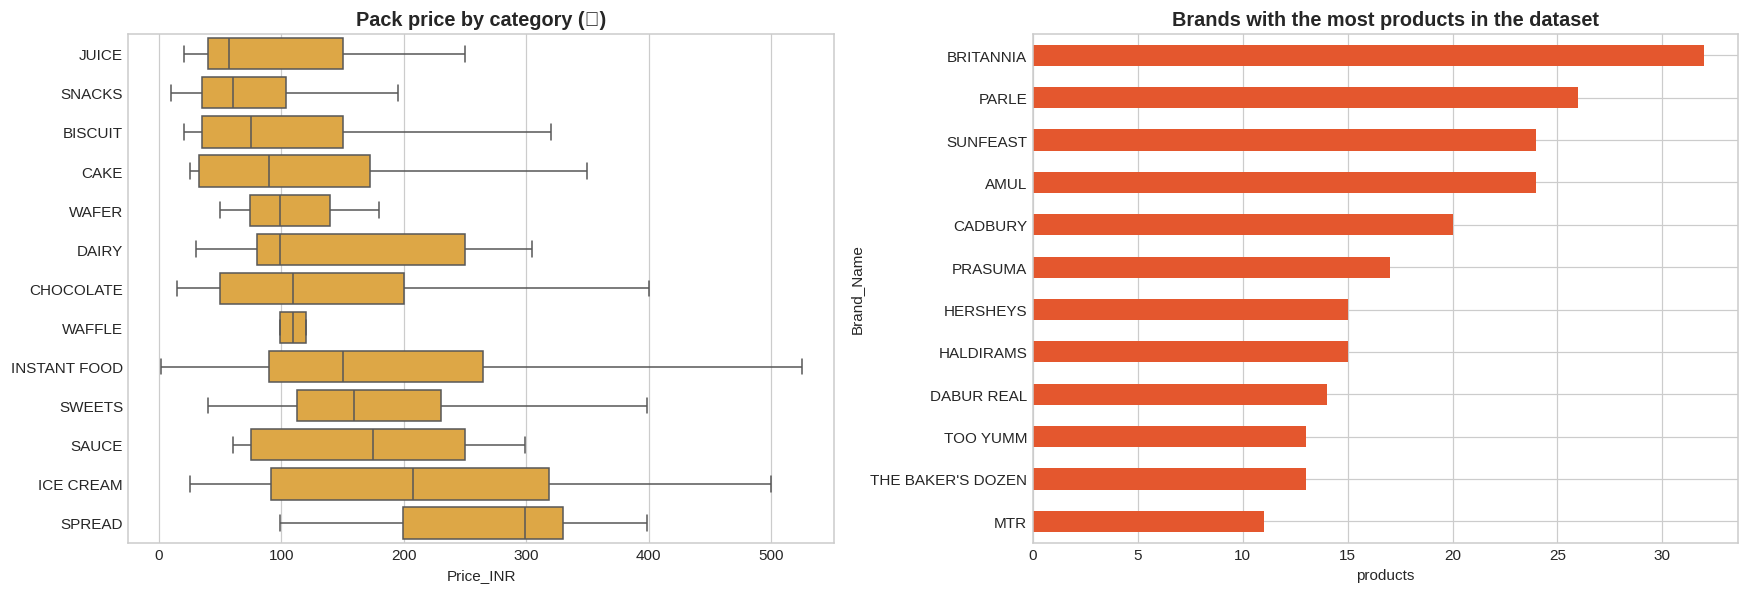

Spearman correlation of pack price with nutrients (per 100 g):
Calories_kcal   -0.07
Protein_g        0.04
Sugar_g          0.02
Fat_g            0.00
Fibre_g          0.19
Name: Price_INR, dtype: float64


In [30]:
fig, axes = plt.subplots(1, 2, figsize=(16, 5.5))
order_p = pkg_std.groupby('Category')['Price_INR'].median().sort_values().index
sns.boxplot(data=pkg_std, y='Category', x='Price_INR', order=order_p, ax=axes[0], color='#F6AE2D', showfliers=False)
axes[0].set(title='Pack price by category (₹)', ylabel='')

top_brands = pkg_std['Brand_Name'].value_counts().head(12)
top_brands.sort_values().plot(kind='barh', ax=axes[1], color='#E4572E')
axes[1].set(title='Brands with the most products in the dataset', xlabel='products')
plt.tight_layout()
plt.show()

print('Spearman correlation of pack price with nutrients (per 100 g):')
print(pkg_std[['Price_INR'] + ['Calories_kcal', 'Protein_g', 'Sugar_g', 'Fat_g', 'Fibre_g']].corr(method='spearman')['Price_INR'].drop('Price_INR').round(2))

> **Price caveat:** `Price_INR` is the pack price and pack weight isn't recorded, so price per 100 g can't be computed. Treat these as indicative only.

## 12. Key findings

### What the combined data says

**1. Packaged foods are far more energy- and sugar-dense.** Median packaged item: **401 kcal / 100 g** vs **175 kcal** for traditional dishes (2.3×), and **15 g sugar vs 2.8 g** (5.4×). Both differences are highly significant with medium effect sizes. Carbohydrate shows the biggest gap (55 g vs 12 g, large effect).

**2. Fat is *not* the big differentiator, but it matters more in home cooking.** Median fat is similar (14.5 g vs 9.1 g, negligible effect). Traditional dishes actually get about **half their energy from fat** (vs ~38% for packaged), and fat explains calorie density almost entirely in home cooking (r = 0.92) while packaged calories are driven by fat *and* carbs together.

**3. Sugar gaps are sharpest in sweets.** Packaged sweets/chocolates/ice creams have a median **~46 g sugar / 100 g**, over 3× traditional desserts (~15 g). The top-10 sugar list is entirely packaged candy (90–98 g).

**4. Salt lives in packaged snacks, meals and sauces.** Packaged snacks (~640 mg sodium) and instant meals (~380 mg) carry **4–7× the sodium** of their traditional equivalents. Traditional snacks, by contrast, are much fattier (fried namkeen, chips).

**5. Red flags.** By FSA thresholds, **69% of packaged items** are "high" in fat, sugar or salt, and **29% are high in two or more**, versus 36% and 5% for traditional dishes.

**6. Nutrient profiles form distinct clusters.** K-Means finds one cluster that is **99% packaged** (energy-dense, sugary, ~475 kcal biscuits/chocolates/snacks) and one that is ~75% packaged (sugary drinks/juices), while low-energy savoury dishes and fibre/micronutrient-bearing meals are almost entirely traditional.

**7. Ingredients.** Two-thirds of packaged biscuits and bakery items use **palm oil** and three-quarters use **maida**. Products listing palm oil have **~5× the saturated fat** (10.5 g vs 2.1 g median, p < 1e-30). A third of packaged snacks list flavour enhancers such as MSG.

**8. Price does not track nutrition.** Pack price has essentially no correlation with calories, sugar, fat or protein (|ρ| < 0.1); fibre shows only a weak positive link.

### Caveats to keep in mind

- **Cooked vs as-sold.** Traditional values are for cooked dishes (which contain water); many packaged items (instant mixes, biscuits, snacks) are dry. This inflates packaged energy density, especially in the *Meals* group, so within-group comparisons of sweets, snacks and beverages are the fairest.
- **Undeclared ≠ zero.** 70–92% of packaged items report 0 fibre, calcium or iron because Indian labels don't require these. Those three comparisons reflect labelling, not true content.
- **Data quality fixes applied:** 4 kJ-as-kcal labels converted, 72 per-serving labels rescaled to 100 g, 32 physically impossible packaged rows removed, and 35 traditional soups/pulaos with implausible sodium (up to 14 g per 100 g) blanked.
- **Food groups for traditional dishes** come from keyword rules on the dish name, so a handful of items will be misfiled (e.g. "Coffee ice cream" as a beverage). This affects group-level medians only slightly.